## 1. Team Formation and Dataset

This repository will be used by the team **Waveform Warriors** to collaborate on the Data Analysis Final assignment.

Team consists of:

- Juanith Mathew Thomas
- Kornel Lengl

We will work on analysing **Rossmann Store Sales** found on Kaggle: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales

The *train.csv* and *test.csv* datasets have several entries of 1115 stores, their sales, ongoing discounts, etc. over a period of about 3 years. <br>
Features like their competitor stores and distance to them are also mentioned in the metadata dataset *store.csv.*

In [573]:
import pandas as pd
import numpy as np
from sklearn.model_selection import *
import matplotlib.pyplot as plt
from random import *
import seaborn as sns

In [574]:
df_complete = pd.read_csv("data/train.csv", low_memory=False)

In [575]:
df_tail = df_complete.tail(n=406974)                        # Taking 365 day sales of each 1115 stores. Data in head is skewed.
df_head = df_complete.head(n=406975)

#df = df_tail.drop(df_tail[df_tail['Store'] == 1115].index[0])
# insertion = df_head[df_head['Store'] == 988].sample(1, random_state=42)
# df = pd.concat([df, insertion], ignore_index=True)

df_tail                                                          # This dataset will be used moving forward.

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
610235,1,2,31-12-2013,2362,298,1,0,0,1
610236,2,2,31-12-2013,2148,268,1,0,0,1
610237,3,2,31-12-2013,4081,463,1,0,0,1
610238,4,2,31-12-2013,9813,1323,1,0,0,1
610239,5,2,31-12-2013,2009,241,1,0,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,01-01-2013,0,0,0,0,a,1
1017205,1112,2,01-01-2013,0,0,0,0,a,1
1017206,1113,2,01-01-2013,0,0,0,0,a,1
1017207,1114,2,01-01-2013,0,0,0,0,a,1


## 2. Task Categories and Points

### 2.1: Data Preprocessing and Data Quality


#### • Dataset overview

In [576]:
print ("1. The dimensions of the dataset are: ", df.shape, end="\n\n")                                              # Dimensions
print ("2. The columns in this dataset are: ", df.columns.values, end="\n\n")                                       # Columns
print ("3. The data type of each feature in this dataset: \n" + df.dtypes.to_string(), end="\n\n")                  # Types
print (f"4. Time series range of this dataset is from {min(df['Date'])} to {max(df['Date'])}", end="\n\n")          # Time range
print ("5. The sampling rate of the data is 1 day. Each store tracks and report the daily sales.")      # Sampling rate

1. The dimensions of the dataset are:  (321300, 12)

2. The columns in this dataset are:  ['Store' 'DayOfWeek' 'Sales' 'Customers' 'Open' 'Promo' 'StateHoliday'
 'SchoolHoliday' 'IsWeekend' 'Month' 'WeekOfYear' 'Year']

3. The data type of each feature in this dataset: 
Store             int64
DayOfWeek         int32
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
IsWeekend         int64
Month             int32
WeekOfYear        int64
Year              int32



KeyError: 'Date'

In [ ]:
missing_count = df.isnull().sum()
print (f"6. Missingness summary: \n{missing_count}")                                                                # Missingness summary

6. Missingness summary: 
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
IsWeekend        0
Month            0
WeekOfYear       0
Year             0
dtype: int64


#### • Basic statistical analysis using pandas 

In [ ]:
print ("1. Description of the dataset: ")                      # Descriptives
df.describe()

1. Description of the dataset: 


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,IsWeekend,Month,WeekOfYear,Year
count,321300.000000,321300.000000,321300,321300.000000,321300.000000,321300.0,321300.000000,321300.000000,321300.000000,321300.000000,321300.000000,321300.0
mean,556.725584,2.555114,2013-06-30 14:01:16.638655744,6350.146913,703.774211,1.0,0.420430,0.203321,0.178466,6.476303,26.236041,2013.0
min,1.000000,0.000000,2013-01-01 00:00:00,133.000000,18.000000,1.0,0.000000,0.000000,0.000000,1.000000,1.000000,2013.0
25%,276.000000,1.000000,2013-04-02 00:00:00,4644.000000,502.000000,1.0,0.000000,0.000000,0.000000,4.000000,13.000000,2013.0
50%,557.000000,3.000000,2013-07-03 00:00:00,6063.000000,653.000000,1.0,0.000000,0.000000,0.000000,7.000000,26.000000,2013.0
75%,839.000000,4.000000,2013-09-27 00:00:00,7820.000000,848.000000,1.0,1.000000,0.000000,0.000000,9.000000,39.000000,2013.0
max,1115.000000,6.000000,2013-12-31 00:00:00,12584.000000,3908.000000,1.0,1.000000,1.000000,1.000000,12.000000,52.000000,2013.0
std,323.184176,1.716488,NaN,2297.554778,293.934621,0.0,0.493629,0.402470,0.382905,3.414721,14.895697,0.0


In [ ]:
print ("2. Grouped stats of the dataset: ")                    # Grouped stats
df.info()                                                      # Not sure if this is exactly what's expected.

2. Grouped stats of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321300 entries, 0 to 321299
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          321300 non-null  int64         
 1   DayOfWeek      321300 non-null  int32         
 2   Date           321300 non-null  datetime64[ns]
 3   Sales          321300 non-null  int64         
 4   Customers      321300 non-null  int64         
 5   Open           321300 non-null  int64         
 6   Promo          321300 non-null  int64         
 7   StateHoliday   321300 non-null  object        
 8   SchoolHoliday  321300 non-null  int64         
 9   IsWeekend      321300 non-null  int64         
 10  Month          321300 non-null  int32         
 11  WeekOfYear     321300 non-null  int64         
 12  Year           321300 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(8), object(1)
memory usage: 28.2

In [ ]:
Q1 = df['Sales'].quantile(0.25)                                # Quantiles and the IQR value
Q2 = df['Sales'].quantile(0.50)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Median = {Q2}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

Q1 = 4644.0
Median = 6063.0
Q3 = 7820.0
IQR = 3176.0


#### • Original data quality analysis with visualization 

In [ ]:
missing = df.isnull().sum()                                     # Missingness patterns
missing_pct = (missing / len(df)) * 100

missing_pct

Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
IsWeekend        0.0
Month            0.0
WeekOfYear       0.0
Year             0.0
dtype: float64

In [ ]:
for col in df.select_dtypes(include=['number']).columns:        # Outliers
    if col == "Open":
        print("Open:            These are binary values, so applying IQR on them is basically useless.")
        print(f"  0: {sum(df['Open'] == 0)} rows, 1: {sum(df['Open'] == 1)} rows")
    
    elif col == "Promo":
        print("Promo:")
        print(f"  0: {sum(df['Promo'] == 0)} rows, 1: {sum(df['Promo'] == 1)} rows")

    elif col == "SchoolHoliday":
        print("SchoolHoliday:")
        print(f"  0: {sum(df['SchoolHoliday'] == 0)} rows, 1: {sum(df['SchoolHoliday'] == 1)} rows")

    else:
        print(f"{col}:")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR                                  # 'StateHoliday' and 'Date' not included since those are objects, not numeric data types.
        
        out_low  = df[df[col] < lower].shape[0]
        out_high = df[df[col] > upper].shape[0]
        
        print(f"  Range: {df[col].min():.2f} → {df[col].max():.2f}")
        print(f"  IQR outlier bounds: {lower:.2f} ↔ {upper:.2f}")
        print(f"  Outliers: {out_low} below, {out_high} above")

Store:
  Range: 1.00 → 1115.00
  IQR outlier bounds: -568.50 ↔ 1683.50
  Outliers: 0 below, 0 above
DayOfWeek:
  Range: 0.00 → 6.00
  IQR outlier bounds: -3.50 ↔ 8.50
  Outliers: 0 below, 0 above
Sales:
  Range: 133.00 → 12584.00
  IQR outlier bounds: -120.00 ↔ 12584.00
  Outliers: 0 below, 0 above
Customers:
  Range: 18.00 → 3908.00
  IQR outlier bounds: -17.00 ↔ 1367.00
  Outliers: 0 below, 9029 above
Open:            These are binary values, so applying IQR on them is basically useless.
  0: 0 rows, 1: 321300 rows
Promo:
  0: 186216 rows, 1: 135084 rows
SchoolHoliday:
  0: 255973 rows, 1: 65327 rows
IsWeekend:
  Range: 0.00 → 1.00
  IQR outlier bounds: 0.00 ↔ 0.00
  Outliers: 0 below, 57341 above
Month:
  Range: 1.00 → 12.00
  IQR outlier bounds: -3.50 ↔ 16.50
  Outliers: 0 below, 0 above
WeekOfYear:
  Range: 1.00 → 52.00
  IQR outlier bounds: -26.00 ↔ 78.00
  Outliers: 0 below, 0 above
Year:
  Range: 2013.00 → 2013.00
  IQR outlier bounds: 2013.00 ↔ 2013.00
  Outliers: 0 below, 0 a

In [ ]:
exact_dup_rows = df.duplicated(keep=False).sum()                # Duplicate entries
print(f"Exact duplicate rows: {exact_dup_rows} out of {len(df)}")

Exact duplicate rows: 0 out of 321300


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)                         # Timestamp gaps
sorted_time = df['Date'].dropna().sort_values()
time_gaps = sorted_time.diff()

print(f"Min gap: {time_gaps.min()}")
print(f"Max gap: {time_gaps.max()}")
print(f"Mean gap (of the whole dataset): {time_gaps.mean()}")

random_shop = randint(1, 1115)
dates_series = pd.Series(df[df['Store'] == random_shop]['Date'].sort_values().unique())
print(f"\nMean gap (of shop no. {random_shop}): {dates_series.diff().mean()}")

Min gap: 0 days 00:00:00
Max gap: 1 days 00:00:00
Mean gap (of the whole dataset): 0 days 00:01:37.882657586

Mean gap (of shop no. 767): 1 days 04:56:36.677740863


In [ ]:
# Only the columns 'Sales' can have inconsistent units.
Serial = 0
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
lowerlimit = Q1 - 1.5 * (Q3 - Q1)
upperlimit = Q3 + 1.5 * (Q3 - Q1)

for sales in df['Sales']:
    if sales > upperlimit:
        Serial += 1

print (f"Number of outlier sales days {Serial} out of {len(df['Sales'])}")

# The dataset was obtained from Kaggle.
# Metadata has confirmed that all the stores from which the data was obtained were German stores.
# It is reasonably safe to assume all sales were in Euros since there's no great way of figuring out inconsistent units.
# Outliers do exist but nothing too drastic to suggest sale reports in a considerably weaker currency.

Number of outlier sales days 0 out of 321300


#### • Data preprocessing pipeline

In [ ]:
df_clean = df[df['Sales'] > 0].reset_index(drop=True)                       # Cleaning steps
remaining_stores = len(df) - len(df_clean)

print(f"Removed {remaining_stores} closed store days ({100*(remaining_stores)/len(df):0.2f}%)")

Removed 0 closed store days (0.00%)


In [ ]:
print(df_clean.isnull().sum())                                              # No missing data

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
IsWeekend        0
Month            0
WeekOfYear       0
Year             0
dtype: int64


In [ ]:
df_clean_again = df_clean[(df_clean['Sales'] >= lowerlimit) & (df_clean['Sales'] <= upperlimit)]
remaining_stores = len(df_clean) - len(df_clean_again)                      # Removing outliers

print(f"Removed {remaining_stores} outlier store entries ({100*(remaining_stores)/len(df):0.2f}%)")

Removed 0 outlier store entries (0.00%)


In [ ]:
df_clean_again = df_clean_again.copy()                                      # Basic feature engineering
df_clean_again['IsWeekend'] = (df_clean_again['DayOfWeek'] >= 5).astype(int)

In [ ]:
df_complete                         # Original dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,31-07-2015,5263,555,1,1,0,1
1,2,5,31-07-2015,6064,625,1,1,0,1
2,3,5,31-07-2015,8314,821,1,1,0,1
3,4,5,31-07-2015,13995,1498,1,1,0,1
4,5,5,31-07-2015,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,01-01-2013,0,0,0,0,a,1
1017205,1112,2,01-01-2013,0,0,0,0,a,1
1017206,1113,2,01-01-2013,0,0,0,0,a,1
1017207,1114,2,01-01-2013,0,0,0,0,a,1


In [ ]:
df_clean_again                      # Cleaned dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend,Month,WeekOfYear,Year
0,1,1,2013-12-31,2362,298,1,0,0,1,0,12,1,2013
1,2,1,2013-12-31,2148,268,1,0,0,1,0,12,1,2013
2,3,1,2013-12-31,4081,463,1,0,0,1,0,12,1,2013
3,4,1,2013-12-31,9813,1323,1,0,0,1,0,12,1,2013
4,5,1,2013-12-31,2009,241,1,0,0,1,0,12,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
321295,682,1,2013-01-01,3375,566,1,0,a,1,0,1,1,2013
321296,733,1,2013-01-01,10765,2377,1,0,a,1,0,1,1,2013
321297,769,1,2013-01-01,5035,1248,1,0,a,1,0,1,1,2013
321298,948,1,2013-01-01,4491,1039,1,0,a,1,0,1,1,2013


Commentary on what changed in the original vs. cleaned dataset.

Firstly, the size of the dataset reduced. Instead of having 700-1000 entries for each shop, skewed in favor of some, the data was seived to obtain 365 entries of each 1115 shop. <br>
Outliers were removed. Duplicates were checked for, none present. <br>
Days on which stores had 0 sales were removed since they could negatively impact the pattern learning of the LR model. <br>
Feature engineering added 1 feature to the dataset namely 'IsWeekend' which might help the linear regression better predict the sales of a shop that remains open (and has more sales) on the weekend. 

### 2.2: Visualization and Exploratory Analysis

#### • Time-series visualizations

Text(0, 0.5, 'Sales')

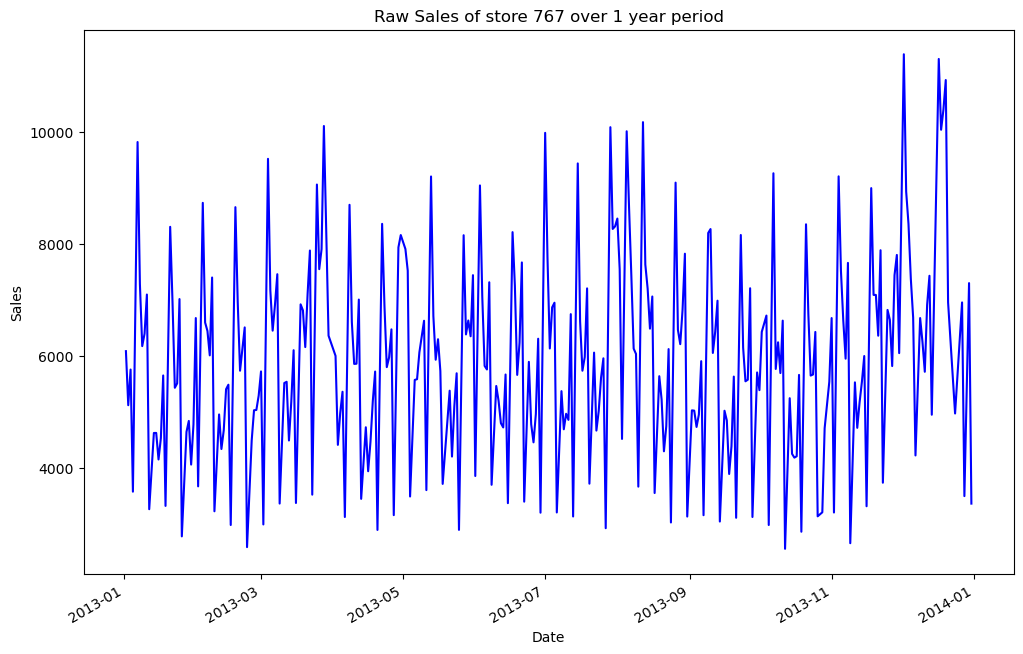

In [ ]:
df = df_clean_again               # Reassigning the cleaned dataset to df

store_data = df[df['Store'] == random_shop].copy()
store_data['Date'] = pd.to_datetime(store_data['Date'])
store_data = store_data.sort_values('Date').set_index('Date')

plt.figure(figsize=(12, 8))
store_data['Sales'].plot(title=f"Raw Sales of store {random_shop} over 1 year period", color='blue')       # Raw
plt.ylabel('Sales')

Text(0, 0.5, 'Sales')

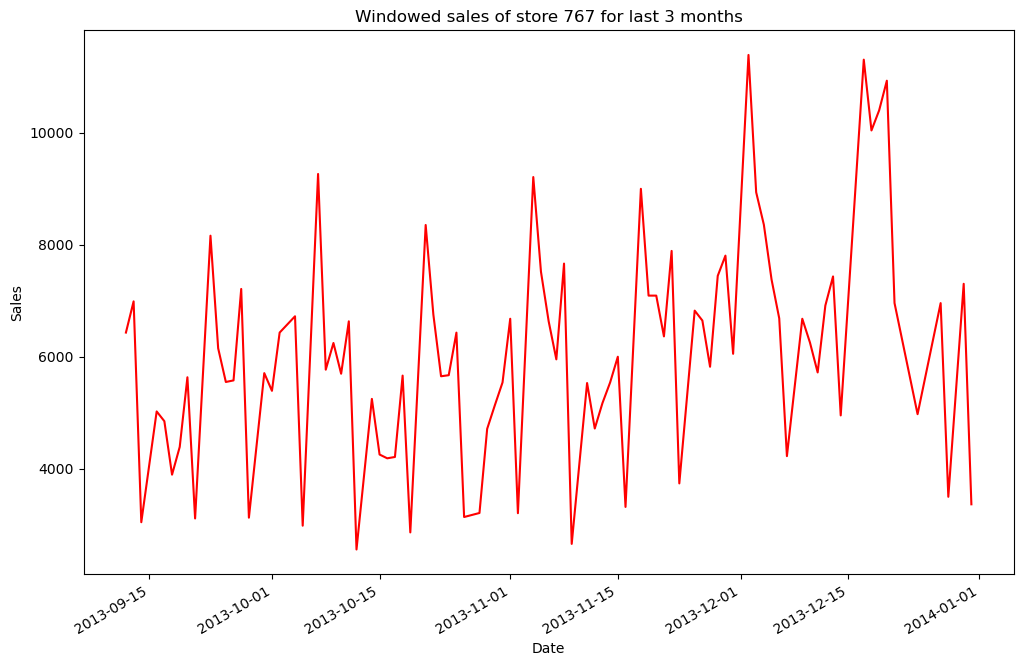

In [ ]:
plt.figure(figsize=(12, 8))                                                                                 # Windowed
store_data['Sales'].tail(90).plot(title=f"Windowed sales of store {random_shop} for last 3 months", color='red')
plt.ylabel('Sales')

#### • Distribution analysis with histograms and density style plots 

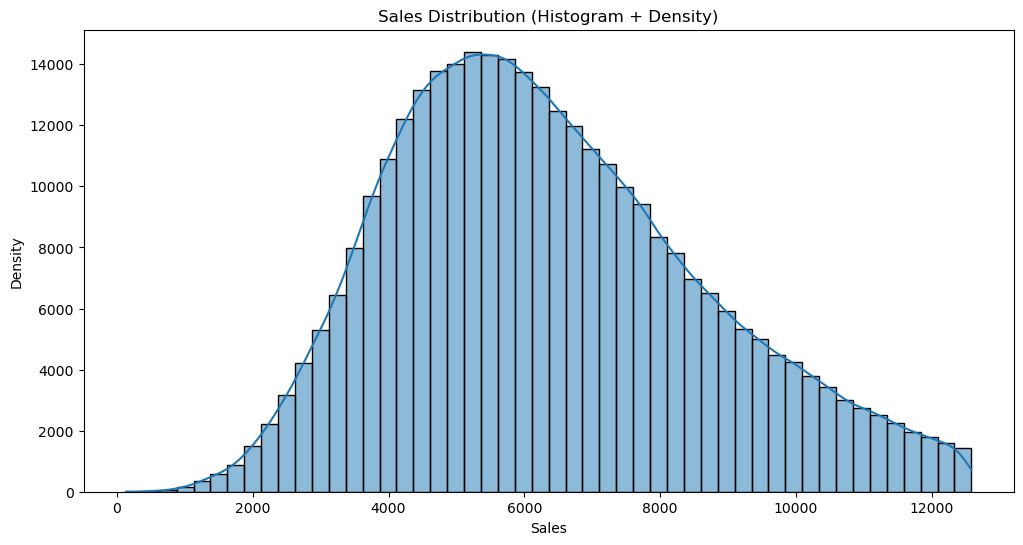

In [ ]:
plt.figure(figsize=(12, 6)) 
sns.histplot(data=df, x='Sales', kde=True, bins=50)                 # kernel density estimate (KDE) for the density curve on the bins
plt.title(f'Sales Distribution (Histogram + Density)')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.show()

#### • Correlation analysis and heatmaps

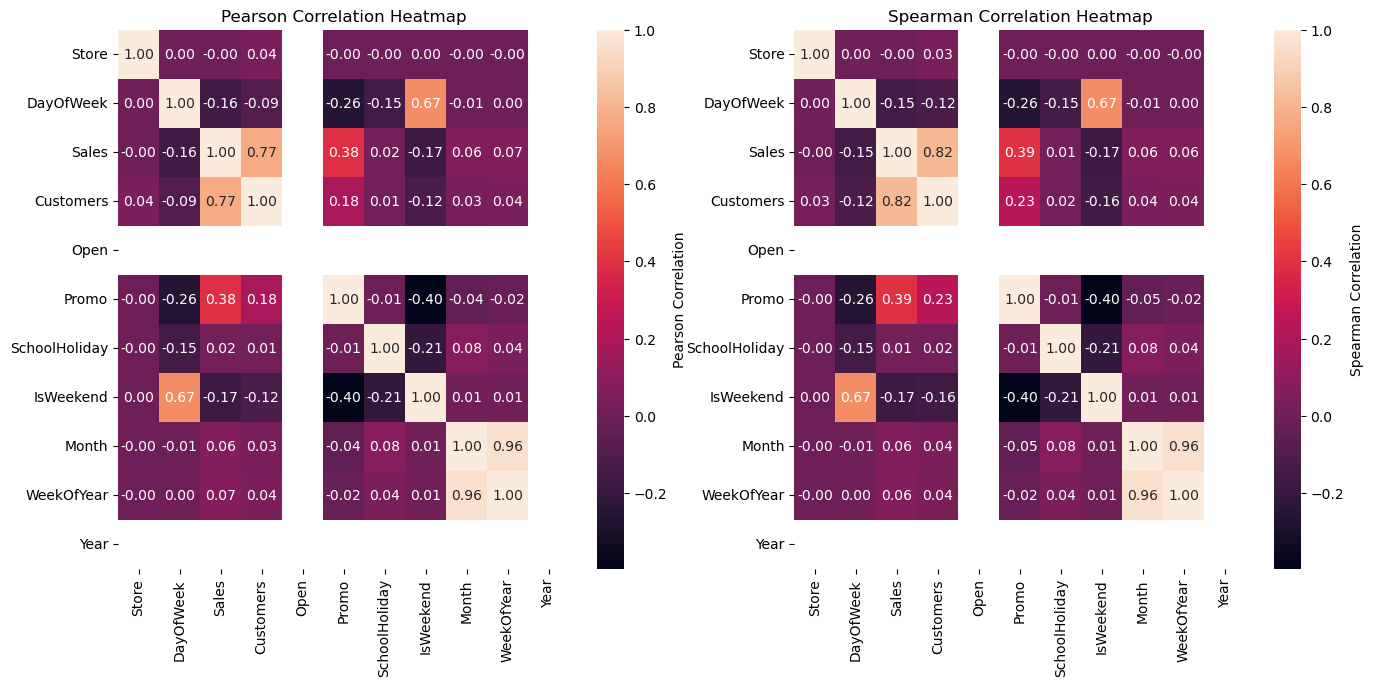

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr_data = df[numeric_cols]

pearson_corr = corr_data.corr(method='pearson')                             # 1. Pearson correlation
spearman_corr = corr_data.corr(method='spearman')                           # 2. Spearman correlation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pearson_corr, annot=True, ax=ax1, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'})
ax1.set_title('Pearson Correlation Heatmap')

sns.heatmap(spearman_corr, annot=True, ax=ax2, fmt='.2f', cbar_kws={'label': 'Spearman Correlation'})
ax2.set_title('Spearman Correlation Heatmap')

plt.show()

##### Interpretation of the above heatmaps

As expected, the correlation is quite similar for both in most aspects, subtle differences caused by the difference in method of correlation calculation. <br>
Since our dataset:
1. Doesn't have outliers
2. Is sufficiently large
3. Not skewed towards the tail

Pearson correlation is pretty sufficient for correlation analysis and we don't necessarily need to employ spearman method.

#### • Store specific daily or periodic pattern analysis 

In [ ]:
store_data

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend,Month,WeekOfYear,Year
Date,,,,,,,,,,,,
2013-01-02,767,2,6087,666,1,0,0,1,0,1,1,2013
2013-01-03,767,3,5122,573,1,0,0,1,0,1,1,2013
2013-01-04,767,4,5759,645,1,0,0,1,0,1,1,2013
2013-01-05,767,5,3578,372,1,0,0,0,1,1,1,2013
2013-01-07,767,0,9821,887,1,1,0,0,0,1,2,2013
...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-24,767,1,4974,575,1,0,0,1,0,12,52,2013
2013-12-27,767,4,6957,728,1,0,0,1,0,12,52,2013
2013-12-28,767,5,3499,373,1,0,0,0,1,12,52,2013


In [ ]:
store_data = store_data.reset_index()

In [ ]:
store_data

,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend,Month,WeekOfYear,Year
0,2013-01-02,767,2,6087,666,1,0,0,1,0,1,1,2013
1,2013-01-03,767,3,5122,573,1,0,0,1,0,1,1,2013
2,2013-01-04,767,4,5759,645,1,0,0,1,0,1,1,2013
3,2013-01-05,767,5,3578,372,1,0,0,0,1,1,1,2013
4,2013-01-07,767,0,9821,887,1,1,0,0,0,1,2,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,2013-12-24,767,1,4974,575,1,0,0,1,0,12,52,2013
298,2013-12-27,767,4,6957,728,1,0,0,1,0,12,52,2013
299,2013-12-28,767,5,3499,373,1,0,0,0,1,12,52,2013
300,2013-12-30,767,0,7302,809,1,0,0,1,0,12,1,2013


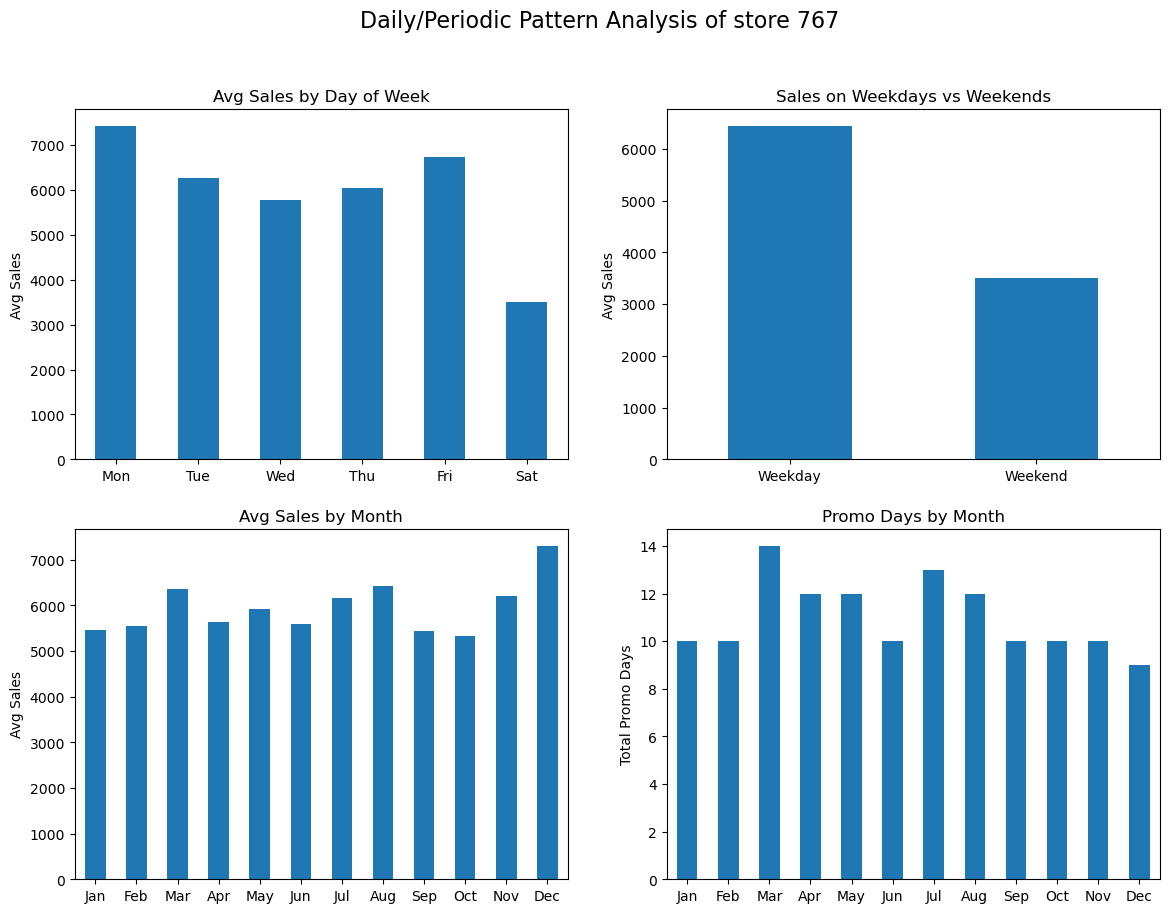

In [577]:
store_data['date'] = pd.to_datetime(store_data['Date'])
store_data['dayOfWeek'] = store_data['Date'].dt.dayofweek
store_data['month'] = store_data['Date'].dt.month


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Daily/Periodic Pattern Analysis of store {random_shop}', fontsize=16)

day_means = store_data.groupby('DayOfWeek')['Sales'].mean()                             # Day-of-week pattern
day_means.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
day_means.plot(kind='bar', ax=axes[0, 0], title='Avg Sales by Day of Week')
axes[0, 0].set_ylabel('Avg Sales')
axes[0, 0].tick_params(axis='x', rotation=0)

day_means = store_data.groupby('IsWeekend')['Sales'].mean()                            # Weekend vs Weekday pattern
day_means.index = ['Weekday', 'Weekend']
day_means.plot(kind='bar', ax=axes[0, 1], title='Sales on Weekdays vs Weekends')
axes[0, 1].set_ylabel('Avg Sales')
axes[0, 1].tick_params(axis='x', rotation=0)

month_means = store_data.groupby('month')['Sales'].mean()                             # Monthly pattern
month_means.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_means.plot(kind='bar', ax=axes[1, 0], title='Avg Sales by Month')
axes[1, 0].set_ylabel('Avg Sales')
axes[1, 0].tick_params(axis='x', rotation=0)

day_means = store_data.groupby('month')['Promo'].sum()                              # Promo pattern
day_means.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_means.plot(kind='bar', ax=axes[1, 1], title='Promo Days by Month')
axes[1, 1].set_ylabel('Total Promo Days')
axes[1, 1].tick_params(axis='x', rotation=0)



#### • General daily or periodic pattern analysis 

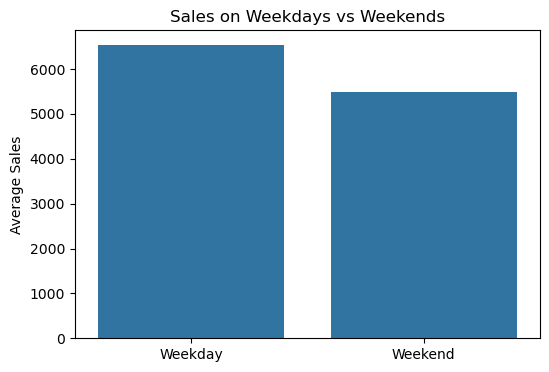

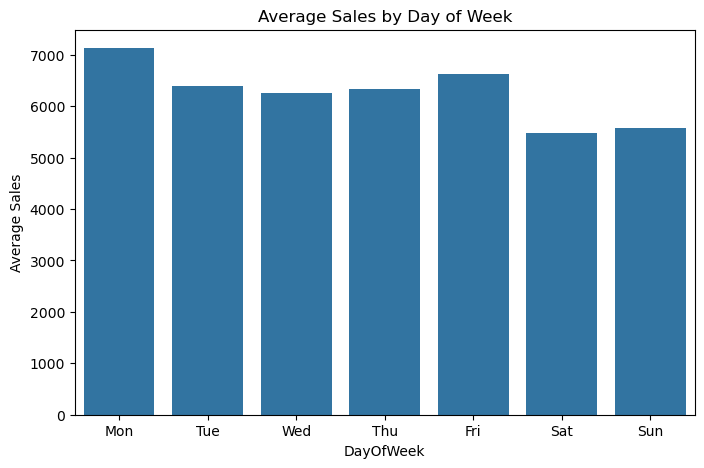

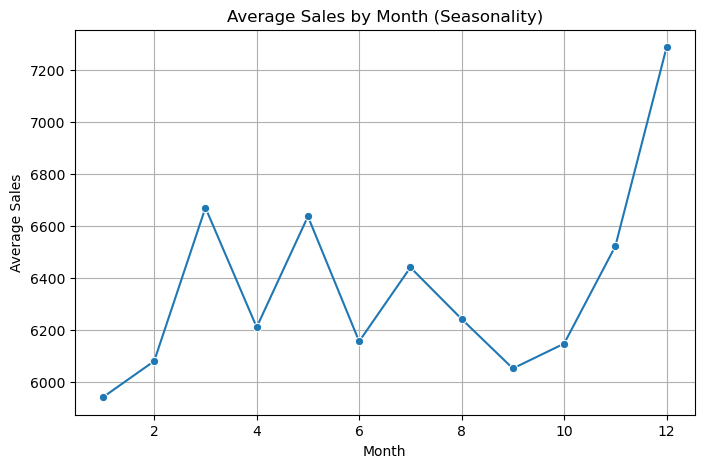

In [578]:



weekend_means = df.groupby('IsWeekend')['Sales'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=['Weekday','Weekend'], y=weekend_means.values)
plt.title('Sales on Weekdays vs Weekends')
plt.ylabel('Average Sales')
plt.show()


dow_means = df.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=dow_means.index, y=dow_means.values)
plt.xticks([0,1,2,3,4,5,6], ['Mon','Tue','Wed','Thu','Fri','Sat', 'Sun'])
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.show()

month_means = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=month_means.index, y=month_means.values, marker='o')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()


### Summary of observed patterns

##### Days of the week pattern
Although individual stores show large deviations in sales across different days of the week, across all 1,115 stores Monday is the strongest sales day.

**Evidence**: In the *Average Sales by Day* of Week bar plot, Mondays have the highest mean sales, and Saturdays the lowest.

##### Weekday vs Weekend pattern
Generally, weekdays are stronger sales days than weekends, although several individual stores sell more on Saturdays.

**Evidence**: The *Sales on Weekdays vs Weekends* plot shows a clear preference for weekdays.

##### Monthly sales pattern
December is by far the strongest sales month.

**Evidence**: The *Average Sales by Month (Seasonality)* plot clearly shows that most sales occur in December.

##### Promo vs Seasonality
Seasonality has a stronger influence on sales than promotions.

**Evidence**: The* Promo Days by Month* plot shows that December has the fewest promo days, yet the *Average Sales by Month (Seasonality)* plot shows it has the highest sales. March has the most promo days and the second‑highest sales, which indicates that although promotions have less impact than seasonality, they are still effective.
